# Preneed Funding Model — Massachusetts

Models the full **vehicle × guarantee × payment-mode** matrix for preneed funeral contracts
under Massachusetts law, with a per-beneficiary QFT tax engine and book-level expected values.

**Regulatory basis**

| Provision | What it drives in this model |
|---|---|
| 239 CMR 4.08(6) | Surplus/shortfall settlement — applied *separately* to funeral-home goods/services and to cash-advance items |
| 239 CMR 4.02(5)(d) | The FH% / CA% split that apportions funds at death |
| 239 CMR 4.09(3) | Trust invested per M.G.L. c. 203C (Prudent Investor) — permits equities |
| 239 CMR 4.01 | "Cost-protected" requires **full funding**; drives the installment guarantee flag |
| IRC §685 | QFT election; each beneficiary's separate interest taxed as a separate trust |
| Rev. Proc. 2025-32 | 2026 federal trust/estate brackets and 0% capital-gains threshold |
| M.G.L. c. 62 | Massachusetts fiduciary tax: 5% flat / 8.5% STCG / 4% surtax |

**How to use:** edit the `P = Params(...)` cell below, then *Run All*. Everything downstream is derived.

> Not legal, tax, or investment advice. Contract language and the QFT/composite filing
> questions need Massachusetts counsel and the trustee's tax preparer.


## 1. Setup

In [1]:
from __future__ import annotations
from dataclasses import dataclass, field, replace, asdict
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

INF = float("inf")
pd.set_option("display.float_format", lambda v: f"{v:,.0f}")
plt.rcParams.update({
    "figure.figsize": (11, 5.5), "figure.dpi": 110, "axes.grid": True,
    "grid.alpha": 0.25, "axes.spines.top": False, "axes.spines.right": False,
    "font.size": 10, "axes.titlesize": 12, "axes.titleweight": "bold",
})
usd = FuncFormatter(lambda v, _: f"${v:,.0f}")
pct = FuncFormatter(lambda v, _: f"{v:.1%}")
print("ready")

ready


## 2. Parameters — **edit here**

Every number in the model lives in this cell. Nothing below is hard-coded.

In [2]:
# ---------------------------------------------------------------- TAX CONSTANTS
@dataclass
class FederalTax:
    """2026 trust/estate schedule, Rev. Proc. 2025-32. (upper_bound, rate)"""
    ordinary:     tuple = ((3_300, 0.10), (11_700, 0.24), (16_000, 0.35), (INF, 0.37))
    preferential: tuple = ((3_300, 0.00), (16_250, 0.15), (INF, 0.20))  # LTCG + qual. divs
    niit_rate:      float = 0.038
    niit_threshold: float = 16_000.0

@dataclass
class MassTax:
    """M.G.L. c. 62 fiduciary. MA is FLAT - no compressed brackets."""
    rate_ordinary: float = 0.05     # interest, dividends, long-term capital gains
    rate_stcg:     float = 0.085    # short-term capital gains
    surtax_rate:      float = 0.04
    surtax_threshold: float = 1_000_000.0
    apply_surtax_per_beneficiary: bool = True   # <-- UNSETTLED. Flip to test aggregate.

# ---------------------------------------------------------------- CONTRACT
@dataclass
class Contract:
    price:      float = 12_000.0   # contract price at sale
    fh_share:   float = 0.75       # 4.02(5)(d) split: funeral home goods/services
    buyer_age:  int   = 72         # drives mortality AND commission grid
    pay_years:  int   = 1          # 1 = lump sum; 3/5/10 = installments

# ---------------------------------------------------------------- TRUST
@dataclass
class AssetMix:
    """Fractions of gross return by TAX CHARACTER. Drives the effective rate."""
    interest: float = 0.35   # ordinary fed / 5% MA
    qual_div: float = 0.20   # preferential fed / 5% MA
    ltcg:     float = 0.40   # preferential fed / 5% MA
    stcg:     float = 0.05   # ordinary fed / 8.5% MA  <-- turnover penalty
    def normalized(self):
        s = self.interest + self.qual_div + self.ltcg + self.stcg
        return AssetMix(self.interest/s, self.qual_div/s, self.ltcg/s, self.stcg/s)

@dataclass
class Trust:
    gross_return:   float = 0.055    # prudent-investor balanced portfolio
    fee:            float = 0.0075   # trustee + admin, all-in
    mix: AssetMix = field(default_factory=AssetMix)
    qft_elected:    bool  = True     # False = grantor trust (tax hits the customer)
    composite:      bool  = True     # False = filed as ONE entity -> 37% + NIIT
    fee_deductible: bool  = True     # IRC 67(e) trustee fees
    book_contracts: int   = 800      # only used when composite=False (aggregate filing)

# ---------------------------------------------------------------- INSURANCE
@dataclass
class Insurance:
    label:                  str   = "growth-tilted"
    growth_rate:            float = 0.03
    compound:               bool  = True   # False = SIMPLE growth (ask the carrier!)
    growth_starts_at_paidup: bool = False  # True = no growth during pay period
    commission_rate:        float = 0.08   # of face
    underwriting:           str   = "level"  # level | graded | dollar_for_dollar
    graded_schedule:        tuple = (0.40, 0.70)  # yr1, yr2 fraction of face
    graded_style:           str   = "percent"     # percent | rop
    rop_interest:           float = 0.10
    deduct_unpaid_premiums: bool  = False
    chargeback_years:       int   = 2      # commission clawed back if lapse inside this

# ---------------------------------------------------------------- ECONOMICS
@dataclass
class Economics:
    fh_inflation:       float = 0.035   # your GPL inflation
    ca_inflation:       float = 0.045   # cemetery/vault - historically faster
    commission_tax:     float = 0.30    # ordinary income at receipt (fed + MA)
    sidefund_return:    float = 0.05    # pre-tax return on retained commission
    sidefund_tax:       float = 0.30    # annual tax on side-fund earnings
    estate_collection:  float = 0.85    # % you actually collect when billing an estate
    gross_margin:       float = 0.40    # margin on FH goods/services at need
    discount_rate:      float = 0.06    # for PV of book-level expected value
    lapse_rate:         float = 0.00    # annual lapse on installment contracts

# ---------------------------------------------------------------- MORTALITY
@dataclass
class Gompertz:
    """mu(x) = A + B*c^x.  Calibrated: mu(70)=2.2%, mu(80)=5.9%, mu(90)=16.0%,
    life expectancy at 72 = 13.9 yrs.  Replace with your own conversion data."""
    A: float = 0.0002
    B: float = 2.00e-05
    c: float = 1.105

# ---------------------------------------------------------------- MASTER
@dataclass
class Params:
    contract: Contract  = field(default_factory=Contract)
    trust:    Trust     = field(default_factory=Trust)
    econ:     Economics = field(default_factory=Economics)
    fed:      FederalTax= field(default_factory=FederalTax)
    mass:     MassTax   = field(default_factory=MassTax)
    mort:     Gompertz  = field(default_factory=Gompertz)

P = Params()

# The two ends of the carrier commission/growth frontier
GROWTH_TILTED  = Insurance("growth-tilted",     growth_rate=0.030, commission_rate=0.08)
COMMISSION_TILTED = Insurance("commission-tilted", growth_rate=0.010, commission_rate=0.24)
GRADED         = Insurance("graded / GI",       growth_rate=0.020, commission_rate=0.15,
                           underwriting="graded")

HORIZON = 30   # max years modeled
print(f"contract ${P.contract.price:,.0f} | age {P.contract.buyer_age} | "
      f"pay over {P.contract.pay_years}y | FH share {P.contract.fh_share:.0%}")

contract $12,000 | age 72 | pay over 1y | FH share 75%


## 3. Tax engine

Two separate tracks. **Ordinary income** (interest, non-qualified dividends, short-term gains)
starts at 10% from the first dollar — trusts get no standard deduction and QFTs get no personal
exemption. **Preferential income** (qualified dividends, long-term gains) stacks *on top* of
ordinary income and is taxed at 0% while total taxable income stays under $3,300.

In [3]:
def _bracket_tax(income, brackets):
    tax, lo = 0.0, 0.0
    for hi, rate in brackets:
        if income <= lo: break
        tax += (min(income, hi) - lo) * rate
        lo = hi
    return tax

def _preferential_tax(ordinary, pref, brackets):
    """Capital gains stack ON TOP of ordinary taxable income (Sch. D worksheet logic)."""
    tax, lo, left = 0.0, 0.0, pref
    for hi, rate in brackets:
        band_lo, band_hi = max(lo, ordinary), hi
        if band_hi > band_lo and left > 0:
            amt = min(left, band_hi - band_lo)
            tax += amt * rate
            left -= amt
        lo = hi
    return tax

def federal_tax(ordinary, preferential, ft):
    ordinary, preferential = max(ordinary, 0.0), max(preferential, 0.0)
    t  = _bracket_tax(ordinary, ft.ordinary)
    t += _preferential_tax(ordinary, preferential, ft.preferential)
    total = ordinary + preferential
    if total > ft.niit_threshold:
        t += ft.niit_rate * (total - ft.niit_threshold)
    return t

def ma_tax(interest_div, ltcg, stcg, mt):
    t = (max(interest_div,0)+max(ltcg,0))*mt.rate_ordinary + max(stcg,0)*mt.rate_stcg
    base = interest_div + ltcg + stcg
    if base > mt.surtax_threshold:
        t += mt.surtax_rate * (base - mt.surtax_threshold)
    return t

# ---- verification against the hand calculations -------------------------------
_ft, _mt = FederalTax(), MassTax()
assert abs(federal_tax(570, 0, _ft) - 57.0) < 1e-9          # all interest -> 10%
assert abs(federal_tax(120, 450, _ft) - 12.0) < 1e-9        # equity-tilted -> only ord. taxed
assert federal_tax(0, 570, _ft) == 0.0                       # pure pref -> ZERO federal
assert abs(_preferential_tax(3000, 1000, _ft.preferential) - 105.0) < 1e-9  # stacking
print("tax engine verified")

tax engine verified


In [4]:
def effective_rate_table(income=570.0, ft=None, mt=None):
    ft, mt = ft or P.fed, mt or P.mass
    scenarios = {
        "All interest":                    dict(i=income, q=0, l=0, s=0),
        "All short-term gains (turnover)":  dict(i=0, q=0, l=0, s=income),
        "Balanced (default mix)":          None,
        "Pure qual. divs + LTCG":          dict(i=0, q=income*0.4, l=income*0.6, s=0),
        "Municipal bonds (tax-exempt)":     dict(i=0, q=0, l=0, s=0),
    }
    m = P.trust.mix.normalized()
    scenarios["Balanced (default mix)"] = dict(i=income*m.interest, q=income*m.qual_div,
                                               l=income*m.ltcg,     s=income*m.stcg)
    rows = []
    for name, d in scenarios.items():
        f = federal_tax(d["i"] + d["s"], d["q"] + d["l"], ft)
        a = ma_tax(d["i"] + d["q"], d["l"], d["s"], mt)
        rows.append({"Portfolio": name, "Federal": f, "Massachusetts": a,
                     "Total": f + a, "Effective": (f + a) / income})
    return pd.DataFrame(rows).set_index("Portfolio")

_t = effective_rate_table()
display(_t.style.format({"Federal":"${:,.2f}","Massachusetts":"${:,.2f}",
                         "Total":"${:,.2f}","Effective":"{:.2%}"})
          .set_caption(f"Tax on ${570:,.0f} of income in ONE beneficiary's QFT interest"))

,Federal,Massachusetts,Total,Effective
Portfolio,,,,
All interest,$57.00,$28.50,$85.50,15.00%
All short-term gains (turnover),$57.00,$48.45,$105.45,18.50%
Balanced (default mix),$22.80,$29.50,$52.30,9.18%
Pure qual. divs + LTCG,$0.00,$28.50,$28.50,5.00%
Municipal bonds (tax-exempt),$0.00,$0.00,$0.00,0.00%


In [25]:
# What happens if the trustee files the master trust as ONE entity instead of composite
def filing_comparison(book_size=10_000_000):
    gross = book_size * (P.trust.gross_return - P.trust.fee)
    n = int(book_size / P.contract.price)
    m = P.trust.mix.normalized()
    per = gross / n
    f_pb = federal_tax(per*(m.interest+m.stcg), per*(m.qual_div+m.ltcg), P.fed) * n
    a_pb = ma_tax(per*(m.interest+m.qual_div), per*m.ltcg, per*m.stcg, P.mass) * n
    f_ag = federal_tax(gross*(m.interest+m.stcg), gross*(m.qual_div+m.ltcg), P.fed)
    a_ag = ma_tax(gross*(m.interest+m.qual_div), gross*m.ltcg, gross*m.stcg, P.mass)
    return pd.DataFrame([
        {"Filing method": f"Composite 1041-QFT ({n:,} interests)", "Federal": f_pb,
         "MA": a_pb, "Total tax": f_pb+a_pb, "Effective": (f_pb+a_pb)/gross},
        {"Filing method": "Single Form 1041 (one entity)", "Federal": f_ag,
         "MA": a_ag, "Total tax": f_ag+a_ag, "Effective": (f_ag+a_ag)/gross},
    ]).set_index("Filing method")

_fc = filing_comparison()
display(_fc.style.format({"Federal":"${:,.0f}","MA":"${:,.0f}",
                          "Total tax":"${:,.0f}","Effective":"{:.2%}"})
           .set_caption("$10M master trust — same portfolio, same law, different filing"))
print(f"\nAnnual cost of filing it wrong: "
      f"${_fc['Total tax'].iloc[1] - _fc['Total tax'].iloc[0]:,.0f}")

,Federal,MA,Total tax,Effective
Filing method,,,,
Composite 1041-QFT (833 interests),"$19,000","$24,581","$43,581",9.18%
Single Form 1041 (one entity),"$142,673","$24,581","$167,254",35.21%



Annual cost of filing it wrong: $123,673


## 4. Trust engine

Year-by-year, because the tax depends on the income *composition* and the bracket position
each year. Handles lump-sum and installment deposits. Trustee fees offset ordinary income
first (IRC §67(e)), then preferential.

In [26]:
def deposits(c, T):
    d = np.zeros(T + 1)
    for t in range(1, min(c.pay_years, T) + 1):
        d[t] = c.price / c.pay_years
    return d

def trust_path(p, T):
    """Returns (balance_path[0..T], cumulative_tax, cumulative_fees)."""
    c, tr = p.contract, p.trust
    m = tr.mix.normalized()
    d = deposits(c, T)
    bal = cum_tax = cum_fee = 0.0
    path = [0.0]
    for t in range(1, T + 1):
        bal += d[t]
        gross = bal * tr.gross_return
        fee   = bal * tr.fee
        ded   = fee if tr.fee_deductible else 0.0

        ordinary = gross * (m.interest + m.stcg)
        pref     = gross * (m.qual_div + m.ltcg)
        use = min(ded, ordinary); ordinary -= use
        pref = max(pref - (ded - use), 0.0)

        if not tr.qft_elected:
            tax = 0.0                      # grantor trust: customer pays, corpus untouched
        elif tr.composite:
            # per-beneficiary bracketing: this interest is its own QFT
            tax = (federal_tax(ordinary, pref, p.fed)
                   + ma_tax(gross*(m.interest+m.qual_div), gross*m.ltcg,
                            gross*m.stcg, p.mass))
        else:
            # aggregate filing: book-level income hits 37% + NIIT, allocated back pro-rata
            n = max(tr.book_contracts, 1)
            tax = (federal_tax(ordinary*n, pref*n, p.fed)
                   + ma_tax(gross*n*(m.interest+m.qual_div), gross*n*m.ltcg,
                            gross*n*m.stcg, p.mass)) / n
        cum_tax += tax; cum_fee += fee
        bal += gross - fee - tax
        path.append(bal)
    return np.array(path), cum_tax, cum_fee

_p, _tx, _fe = trust_path(P, 20)
_net = (_p[-1] / P.contract.price) ** (1/20) - 1
print(f"20-yr balance ${_p[-1]:,.0f} | tax ${_tx:,.0f} | fees ${_fe:,.0f}")
print(f"gross {P.trust.gross_return:.2%} -> fees -{P.trust.fee:.2%} -> tax "
      f"-{P.trust.gross_return-P.trust.fee-_net:.2%} = NET {_net:.3%}")

20-yr balance $27,962 | tax $1,587 | fees $2,771
gross 5.50% -> fees -0.75% -> tax -0.43% = NET 4.320%


## 5. Insurance engine

Death benefit depends on underwriting class and how the growth clock is defined —
the two product questions most directors never ask.

In [27]:
def insurance_benefit(p, ins, T):
    c = p.contract
    face, Pyrs = c.price, c.pay_years
    prem_paid = face * min(T, Pyrs) / Pyrs

    if ins.underwriting == "dollar_for_dollar":
        return prem_paid                              # no mortality transfer at all
    if ins.underwriting == "graded" and T <= len(ins.graded_schedule):
        return (prem_paid * (1 + ins.rop_interest) if ins.graded_style == "rop"
                else face * ins.graded_schedule[T - 1])

    yrs = max(0, T - Pyrs) if ins.growth_starts_at_paidup else T
    grown = face * ((1 + ins.growth_rate) ** yrs if ins.compound
                    else (1 + ins.growth_rate * yrs))
    if ins.deduct_unpaid_premiums and T < Pyrs:
        grown -= (face - prem_paid)
    return max(grown, 0.0)

def sidefund(p, ins, T):
    """Commission taken at sale, taxed as ordinary income, invested, taxed annually."""
    e = p.econ
    if T <= ins.chargeback_years and e.lapse_rate > 0:
        pass                                          # chargeback only bites on lapse
    net = p.contract.price * ins.commission_rate * (1 - e.commission_tax)
    r   = e.sidefund_return * (1 - e.sidefund_tax)
    return net * (1 + r) ** T

_rows = []
for ins in (GROWTH_TILTED, COMMISSION_TILTED, GRADED):
    for T in (1, 2, 5, 10, 20):
        _rows.append({"Product": ins.label, "Year": T,
                      "Death benefit": insurance_benefit(P, ins, T),
                      "Commission fund": sidefund(P, ins, T)})
display(pd.DataFrame(_rows).pivot(index="Year", columns="Product",
        values="Death benefit").style.format("${:,.0f}")
        .set_caption("Death benefit by product and duration"))

Product,commission-tilted,graded / GI,growth-tilted
Year,,,
1,"$12,120","$4,800","$12,360"
2,"$12,241","$8,400","$12,731"
5,"$12,612","$13,249","$13,911"
10,"$13,255","$14,628","$16,127"
20,"$14,642","$17,831","$21,673"


## 6. Settlement — 239 CMR 4.08(6)

Funds are apportioned by the 4.02(5)(d) percentages, then cost protection is applied
**separately** to each side. This is the free risk-transfer lever.

In [28]:
def price_at_need(p, T):
    c, e = p.contract, p.econ
    return (c.price * c.fh_share * (1 + e.fh_inflation) ** T,
            c.price * (1 - c.fh_share) * (1 + e.ca_inflation) ** T)

def settle(p, funds, T, guar_fh, guar_ca):
    c, e = p.contract, p.econ
    cost_fh, cost_ca = price_at_need(p, T)
    f_fh, f_ca = funds * c.fh_share, funds * (1 - c.fh_share)

    def side(f, cost, guar):
        if guar:                       # 4.08(6)(a)/(c): keep surplus | (b)/(d): eat shortfall
            return f, 0.0, 0.0
        if f >= cost:                  # 4.08(6)(e)/(g): refund to estate
            return cost, f - cost, 0.0
        billed = cost - f              # 4.08(6)(f)/(h): bill the estate
        return f + billed * e.estate_collection, 0.0, billed

    r1, ref1, bill1 = side(f_fh, cost_fh, guar_fh)
    r2, ref2, bill2 = side(f_ca, cost_ca, guar_ca)
    price, received = cost_fh + cost_ca, r1 + r2
    delivery_cost = cost_fh * (1 - e.gross_margin) + cost_ca   # CA is pass-through, no markup
    return dict(price_at_need=price, funds=funds, received=received,
                gap=received - price, estate_refund=ref1 + ref2,
                estate_billed=bill1 + bill2, profit=received - delivery_cost)

def evaluate(p, vehicle, guar_fh, guar_ca, T, ins=None):
    if vehicle == "trust":
        funds, extra = trust_path(p, T)[0][-1], 0.0
    else:
        funds, extra = insurance_benefit(p, ins, T), sidefund(p, ins, T)
    out = settle(p, funds, T, guar_fh, guar_ca)
    out.update(commission_fund=extra,
               total_resources=out["received"] + extra,
               gap_total=out["gap"] + extra,
               profit=out["profit"] + extra,
               vehicle=vehicle, product=(ins.label if ins else "trust"), year=T)
    return out

print("settlement engine loaded")

settlement engine loaded


## 7. The eight-cell matrix

In [31]:
CELLS = [
    (1, "trust",     "guaranteed",     None),
    (2, "trust",     "non-guaranteed", None),
    (3, "insurance", "guaranteed",     "growth"),
    (4, "insurance", "non-guaranteed", "growth"),
    (5, "insurance", "guaranteed",     "commission"),
    (6, "insurance", "non-guaranteed", "commission"),
    (7, "insurance", "guaranteed",     "graded"),
    (8, "insurance", "non-guaranteed", "graded"),
]
PRODUCTS = {"growth": GROWTH_TILTED, "commission": COMMISSION_TILTED, "graded": GRADED}

def matrix(p, T, guar_ca=None, blended=True):
    """blended=True => cost-protect FH goods/services only, leave cash advances open."""
    rows = []
    for n, veh, guar, prod in CELLS:
        g_fh = (guar == "guaranteed")
        g_ca = g_fh and not blended if guar_ca is None else guar_ca
        r = evaluate(p, veh, g_fh, g_ca, T, PRODUCTS.get(prod))
        rows.append({"#": n, "Vehicle": veh, "Guarantee": guar,
                     "Product": prod or "-", "Funds": r["funds"],
                     "Commission": r["commission_fund"], "Total": r["total_resources"],
                     "Price@need": r["price_at_need"], "Gap": r["gap_total"],
                     "To estate": r["estate_refund"], "Billed": r["estate_billed"]})
    return pd.DataFrame(rows).set_index("#")

def show_matrix(T, **kw):
    df = matrix(P, T, **kw)
    fmt = {c: "${:,.0f}" for c in ("Funds","Commission","Total","Price@need","Gap",
                                   "To estate","Billed")}
    return (df.style.format(fmt)
            .map(lambda v: f"color:{'#b00' if v < 0 else '#070'};font-weight:600",
                 subset=["Gap"])
            .set_caption(f"Year {T} — pay_years={P.contract.pay_years}, "
                         f"blended guarantee (FH only)"))

show_matrix(2)

,Vehicle,Guarantee,Product,Funds,Commission,Total,Price@need,Gap,To estate,Billed
#,,,,,,,,,,
1,trust,guaranteed,-,"$13,059",$0,"$13,069","$12,917",$152,$0,$11
2,trust,non-guaranteed,-,"$13,059",$0,"$12,915","$12,917",$-2,$153,$11
3,insurance,guaranteed,growth,"$12,731",$720,"$13,530","$12,917",$613,$0,$93
4,insurance,non-guaranteed,growth,"$12,731",$720,"$13,609","$12,917",$692,$0,$186
5,insurance,guaranteed,commission,"$12,241","$2,160","$14,584","$12,917","$1,667",$0,$216
6,insurance,non-guaranteed,commission,"$12,241","$2,160","$14,975","$12,917","$2,058",$0,$676
7,insurance,guaranteed,graded,"$8,400","$1,350","$10,749","$12,917","$-2,168",$0,"$1,176"
8,insurance,non-guaranteed,graded,"$8,400","$1,350","$13,589","$12,917",$672,$0,"$4,517"


In [32]:
show_matrix(10)

,Vehicle,Guarantee,Product,Funds,Commission,Total,Price@need,Gap,To estate,Billed
#,,,,,,,,,,
1,trust,guaranteed,-,"$18,318",$0,"$18,385","$17,354","$1,031",$0,$79
2,trust,non-guaranteed,-,"$18,318",$0,"$17,342","$17,354",$-12,"$1,043",$79
3,insurance,guaranteed,growth,"$16,127",$948,"$17,608","$17,354",$254,$0,$627
4,insurance,non-guaranteed,growth,"$16,127",$948,"$18,118","$17,354",$764,$0,"$1,227"
5,insurance,guaranteed,commission,"$13,255","$2,844","$17,243","$17,354",$-112,$0,"$1,345"
6,insurance,non-guaranteed,commission,"$13,255","$2,844","$19,583","$17,354","$2,229",$0,"$4,099"
7,insurance,guaranteed,graded,"$14,628","$1,777","$17,257","$17,354",$-97,$0,"$1,002"
8,insurance,non-guaranteed,graded,"$14,628","$1,777","$18,723","$17,354","$1,368",$0,"$2,726"


In [33]:
show_matrix(20)

,Vehicle,Guarantee,Product,Funds,Commission,Total,Price@need,Gap,To estate,Billed
#,,,,,,,,,,
1,trust,guaranteed,-,"$27,962",$0,"$28,170","$25,143","$3,026",$0,$245
2,trust,non-guaranteed,-,"$27,962",$0,"$25,107","$25,143",$-37,"$3,063",$245
3,insurance,guaranteed,growth,"$21,673","$1,337","$24,555","$25,143",$-588,$0,"$1,817"
4,insurance,non-guaranteed,growth,"$21,673","$1,337","$25,960","$25,143",$817,$0,"$3,470"
5,insurance,guaranteed,commission,"$14,642","$4,011","$21,692","$25,143","$-3,451",$0,"$3,575"
6,insurance,non-guaranteed,commission,"$14,642","$4,011","$27,580","$25,143","$2,436",$0,"$10,501"
7,insurance,guaranteed,graded,"$17,831","$2,507","$22,699","$25,143","$-2,444",$0,"$2,777"
8,insurance,non-guaranteed,graded,"$17,831","$2,507","$26,554","$25,143","$1,410",$0,"$7,312"


### Same matrix on an installment contract

This is where cells 1 and 3 break. Change `pay_years` in the parameter cell to see it live.

In [34]:
P_inst = replace(P, contract=replace(P.contract, pay_years=5))
_m = matrix(P_inst, 2)
display(_m.style.format({c:"${:,.0f}" for c in ("Funds","Commission","Total",
        "Price@need","Gap","To estate","Billed")})
        .map(lambda v: f"color:{'#b00' if v<0 else '#070'};font-weight:600", subset=["Gap"])
        .set_caption("Year 2 death on a 5-YEAR INSTALLMENT contract"))
print("Guaranteed installment TRUST (cell 1):    "
      f"${_m.loc[1,'Gap']:>10,.0f}   <- no counterparty behind the promise")
print("Guaranteed installment LEVEL INSURANCE:   "
      f"${_m.loc[3,'Gap']:>10,.0f}   <- carrier absorbed the mortality risk")
print("Guaranteed installment GRADED INSURANCE:  "
      f"${_m.loc[7,'Gap']:>10,.0f}   <- graded benefit recreates the cell-1 problem")

,Vehicle,Guarantee,Product,Funds,Commission,Total,Price@need,Gap,To estate,Billed
#,,,,,,,,,,
1,trust,guaranteed,-,"$5,116",$0,"$6,813","$12,917","$-6,104",$0,"$1,997"
2,trust,non-guaranteed,-,"$5,116",$0,"$11,747","$12,917","$-1,170",$0,"$7,802"
3,insurance,guaranteed,growth,"$12,731",$720,"$13,530","$12,917",$613,$0,$93
4,insurance,non-guaranteed,growth,"$12,731",$720,"$13,609","$12,917",$692,$0,$186
5,insurance,guaranteed,commission,"$12,241","$2,160","$14,584","$12,917","$1,667",$0,$216
6,insurance,non-guaranteed,commission,"$12,241","$2,160","$14,975","$12,917","$2,058",$0,$676
7,insurance,guaranteed,graded,"$8,400","$1,350","$10,749","$12,917","$-2,168",$0,"$1,176"
8,insurance,non-guaranteed,graded,"$8,400","$1,350","$13,589","$12,917",$672,$0,"$4,517"


Guaranteed installment TRUST (cell 1):    $    -6,104   <- no counterparty behind the promise
Guaranteed installment LEVEL INSURANCE:   $       613   <- carrier absorbed the mortality risk
Guaranteed installment GRADED INSURANCE:  $    -2,168   <- graded benefit recreates the cell-1 problem


## 8. Resources vs. liability across duration

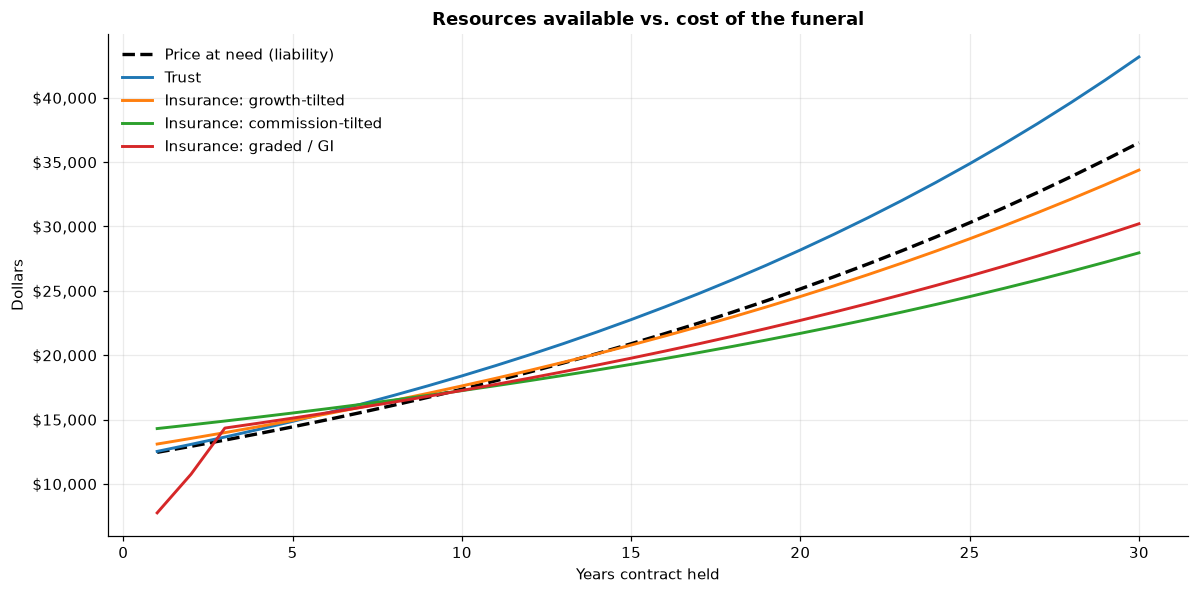

In [35]:
def curves(p, horizon=None):
    horizon = horizon or HORIZON
    yrs = np.arange(1, horizon + 1)
    out = {"Price at need": np.array([sum(price_at_need(p, t)) for t in yrs])}
    out["Trust"] = np.array([evaluate(p,"trust",True,False,t)["total_resources"] for t in yrs])
    for key, ins in PRODUCTS.items():
        out[f"Insurance: {ins.label}"] = np.array(
            [evaluate(p,"insurance",True,False,t,ins)["total_resources"] for t in yrs])
    return yrs, out

yrs, cv = curves(P)
fig, ax = plt.subplots()
ax.plot(yrs, cv["Price at need"], "k--", lw=2.2, label="Price at need (liability)")
for k, v in cv.items():
    if k != "Price at need":
        ax.plot(yrs, v, lw=1.9, label=k)
ax.set(xlabel="Years contract held", ylabel="Dollars",
       title="Resources available vs. cost of the funeral")
ax.yaxis.set_major_formatter(usd); ax.legend(frameon=False); plt.tight_layout(); plt.show()

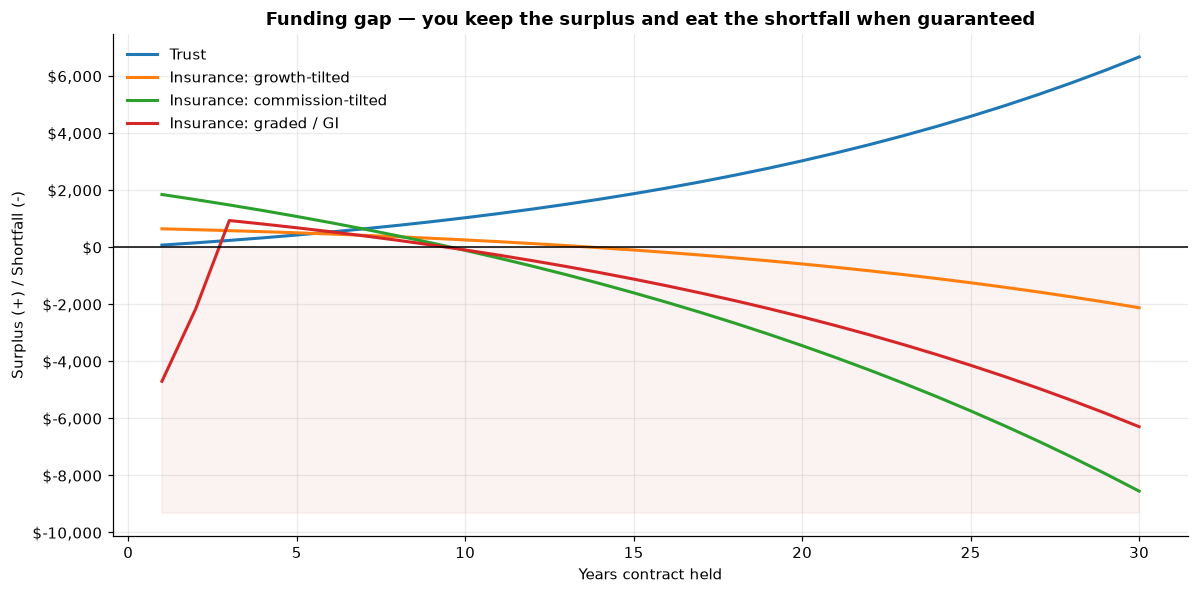

In [14]:
fig, ax = plt.subplots()
for k, v in cv.items():
    if k == "Price at need": continue
    ax.plot(yrs, v - cv["Price at need"], lw=2, label=k)
ax.axhline(0, color="k", lw=1)
ax.fill_between(yrs, 0, ax.get_ylim()[0], color="#b00", alpha=0.05)
ax.set(xlabel="Years contract held", ylabel="Surplus (+) / Shortfall (-)",
       title="Funding gap — you keep the surplus and eat the shortfall when guaranteed")
ax.yaxis.set_major_formatter(usd); ax.legend(frameon=False); plt.tight_layout(); plt.show()

### Effective annual rate

The cleanest view. The commission is a **day-one yield, not a return** — amortized across a
long contract it decays toward nothing, while the trust rate is flat.

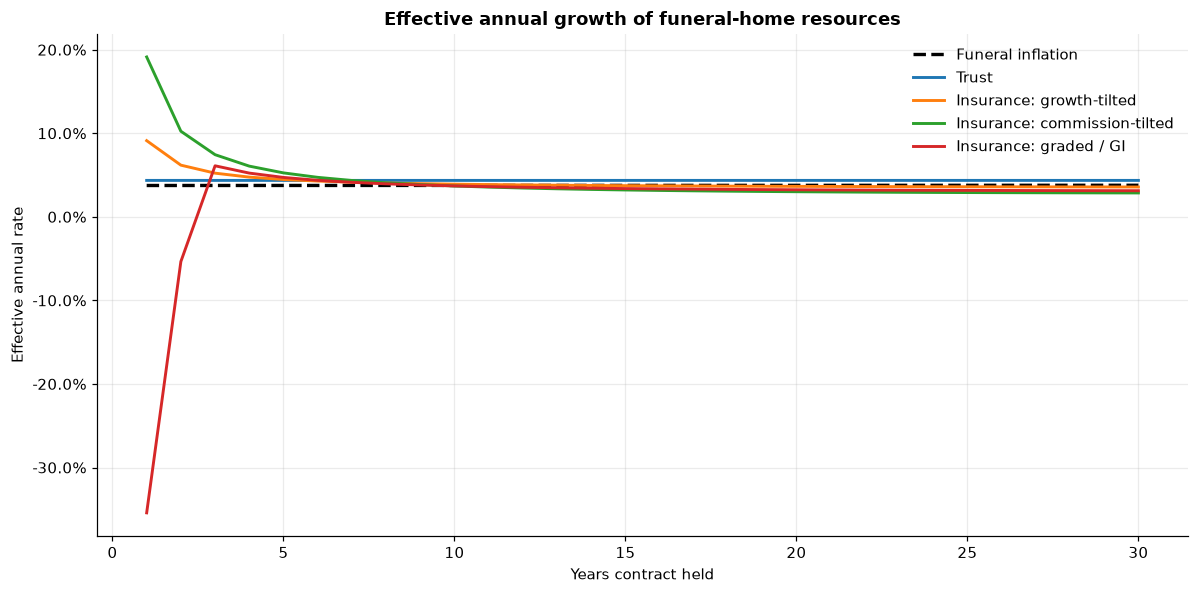

,Funeral inflation,Trust,Insurance: growth-tilted,Insurance: commission-tilted,Insurance: graded / GI
Year,,,,,
2,3.75%,4.36%,6.18%,10.24%,-5.35%
5,3.75%,4.36%,4.47%,5.26%,4.71%
7,3.76%,4.36%,4.15%,4.35%,4.13%
10,3.76%,4.36%,3.91%,3.69%,3.70%
15,3.76%,4.36%,3.73%,3.21%,3.38%
20,3.77%,4.36%,3.64%,3.00%,3.24%
25,3.77%,4.36%,3.60%,2.90%,3.16%
30,3.78%,4.36%,3.57%,2.86%,3.12%


In [15]:
rows = []
for t in yrs:
    r = {"Year": t, "Funeral inflation":
         (sum(price_at_need(P,t))/P.contract.price)**(1/t) - 1}
    for k, v in cv.items():
        if k != "Price at need":
            r[k] = (v[t-1] / P.contract.price) ** (1/t) - 1
    rows.append(r)
eff = pd.DataFrame(rows).set_index("Year")

fig, ax = plt.subplots()
for c_ in eff.columns:
    ax.plot(eff.index, eff[c_], lw=2.2 if "inflation" in c_ else 1.9,
            ls="--" if "inflation" in c_ else "-",
            color="k" if "inflation" in c_ else None, label=c_)
ax.set(xlabel="Years contract held", ylabel="Effective annual rate",
       title="Effective annual growth of funeral-home resources")
ax.yaxis.set_major_formatter(pct); ax.legend(frameon=False); plt.tight_layout(); plt.show()

display(eff.loc[[2,5,7,10,15,20,25,30]].style.format("{:.2%}")
        .set_caption("Effective annual rate by holding period"))

## 9. Book-level expected value

Point estimates at 5, 10 and 20 years are illustrative. What actually matters is the
expectation across your **real duration distribution**. Gompertz mortality by default —
replace `empirical_pmf` with your own at-need conversion data when you have it.

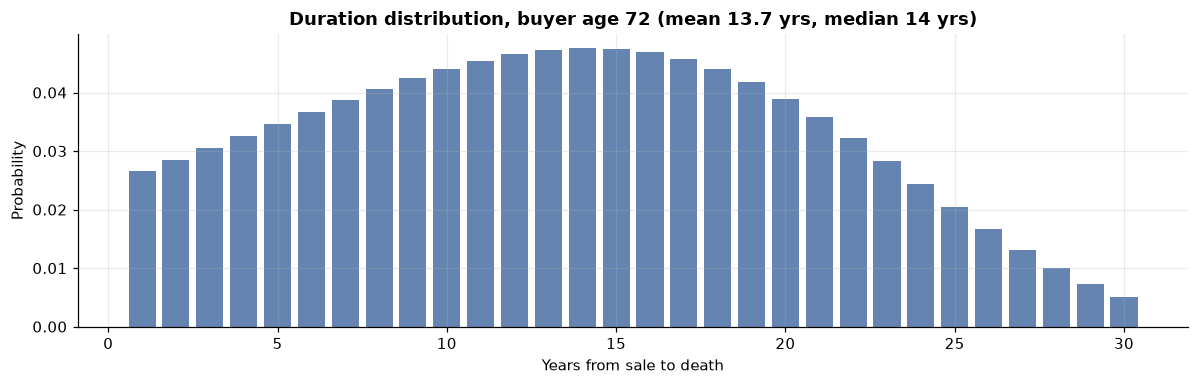

In [16]:
def survival(age, T, g):
    s, out = 1.0, [1.0]
    for t in range(1, T + 1):
        s *= np.exp(-min(g.A + g.B * g.c ** (age + t - 1), 1.0))
        out.append(s)
    return np.array(out)

def death_pmf(age, T, g):
    S = survival(age, T, g)
    pmf = S[:-1] - S[1:]
    return pmf / pmf.sum()          # conditioned on death inside the horizon

pmf = death_pmf(P.contract.buyer_age, HORIZON, P.mort)
# empirical_pmf = np.array([...]); pmf = empirical_pmf / empirical_pmf.sum()

fig, ax = plt.subplots(figsize=(11, 3.6))
ax.bar(yrs, pmf, color="#4a6fa5", alpha=.85)
ax.set(xlabel="Years from sale to death", ylabel="Probability",
       title=f"Duration distribution, buyer age {P.contract.buyer_age} "
             f"(mean {(yrs*pmf).sum():.1f} yrs, median "
             f"{yrs[np.searchsorted(pmf.cumsum(),0.5)]:.0f} yrs)")
plt.tight_layout(); plt.show()

In [17]:
def expected_value(p, pmf=pmf, discount=True):
    """Probability-weighted, optionally PV'd back to the sale date."""
    r = p.econ.discount_rate if discount else 0.0
    rows = []
    for n, veh, guar, prod in CELLS:
        g_fh = (guar == "guaranteed")
        vals = np.array([evaluate(p, veh, g_fh, False, int(t),
                                  PRODUCTS.get(prod))["gap_total"] for t in yrs])
        pv   = vals / (1 + r) ** yrs
        rows.append({"#": n, "Vehicle": veh, "Guarantee": guar, "Product": prod or "-",
                     "E[gap]": float((vals*pmf).sum()),
                     "PV of E[gap]": float((pv*pmf).sum()),
                     "P(shortfall)": float(pmf[vals < 0].sum()),
                     "E[shortfall|loss]": float(-(vals[vals<0]*pmf[vals<0]).sum()
                                                / max(pmf[vals<0].sum(), 1e-12)),
                     "Worst yr": int(yrs[vals.argmin()]), "Worst": float(vals.min())})
    return pd.DataFrame(rows).set_index("#")

ev = expected_value(P)
display(ev.style.format({"E[gap]":"${:,.0f}","PV of E[gap]":"${:,.0f}",
                         "P(shortfall)":"{:.1%}","E[shortfall|loss]":"${:,.0f}",
                         "Worst":"${:,.0f}"})
        .background_gradient(subset=["PV of E[gap]"], cmap="RdYlGn")
        .set_caption("Expected economics per contract, across the full duration "
                     "distribution (blended guarantee: FH only)"))

,Vehicle,Guarantee,Product,E[gap],PV of E[gap],P(shortfall),E[shortfall|loss],Worst yr,Worst
#,,,,,,,,,
1,trust,guaranteed,-,"$1,930",$686,0.0%,$-0,1,$73
2,trust,non-guaranteed,-,$-23,$-8,100.0%,$23,30,$-85
3,insurance,guaranteed,growth,$-127,$46,50.5%,$602,30,"$-2,123"
4,insurance,non-guaranteed,growth,$776,$372,0.0%,$-0,1,$682
5,insurance,guaranteed,commission,"$-1,536",$-315,68.9%,"$2,665",30,"$-8,551"
6,insurance,non-guaranteed,commission,"$2,304","$1,099",0.0%,$-0,1,"$2,037"
7,insurance,guaranteed,graded,"$-1,370",$-473,74.4%,"$2,012",30,"$-6,293"
8,insurance,non-guaranteed,graded,"$1,325",$621,0.0%,$-0,1,$157


In [18]:
# Same thing per $1,000 of face - the number to compare carriers on
per_k = ev[["PV of E[gap]"]] / P.contract.price * 1000
per_k.columns = ["PV per $1,000 of face"]
per_k["Vehicle"] = ev["Vehicle"]; per_k["Guarantee"] = ev["Guarantee"]
per_k["Product"] = ev["Product"]
display(per_k[["Vehicle","Guarantee","Product","PV per $1,000 of face"]]
        .sort_values("PV per $1,000 of face", ascending=False)
        .style.format({"PV per $1,000 of face":"${:,.2f}"})
        .set_caption("THE comparison metric — make every carrier fill in the inputs"))

,Vehicle,Guarantee,Product,"PV per $1,000 of face"
#,,,,
6,insurance,non-guaranteed,commission,$91.61
1,trust,guaranteed,-,$57.16
8,insurance,non-guaranteed,graded,$51.79
4,insurance,non-guaranteed,growth,$31.01
3,insurance,guaranteed,growth,$3.86
2,trust,non-guaranteed,-,$-0.68
5,insurance,guaranteed,commission,$-26.21
7,insurance,guaranteed,graded,$-39.40


## 10. Solvers

Three questions worth answering numerically rather than by argument.

In [19]:
from scipy.optimize import brentq

def crossover_year(p, a=COMMISSION_TILTED, b=GROWTH_TILTED, hi=None):
    """Where does commission-tilted stop beating growth-tilted?"""
    hi = hi or HORIZON
    f = lambda t: (evaluate(p,"insurance",True,False,t,a)["total_resources"]
                   - evaluate(p,"insurance",True,False,t,b)["total_resources"])
    ts = np.arange(1, hi + 1)
    d  = np.array([f(int(t)) for t in ts])
    sign = np.where(np.diff(np.sign(d)))[0]
    if len(sign) == 0: return None
    i = sign[0]
    lo_, hi_ = ts[i], ts[i+1]
    frac = abs(d[i]) / (abs(d[i]) + abs(d[i+1]))
    return lo_ + frac

def breakeven_trust_return(p, target, guar=True):
    """Gross return the trust needs to hit a given PV of E[gap]."""
    def f(r):
        q = replace(p, trust=replace(p.trust, gross_return=r))
        vals = np.array([evaluate(q,"trust",guar,False,int(t))["gap_total"] for t in yrs])
        return float(((vals/(1+q.econ.discount_rate)**yrs)*pmf).sum()) - target
    try:    return brentq(f, 0.001, 0.20)
    except Exception: return np.nan

xo = crossover_year(P)
print(f"Commission/growth crossover:        {xo:.1f} years"
      if xo else "No crossover inside horizon")
print(f"Mean contract duration (age {P.contract.buyer_age}):     {(yrs*pmf).sum():.1f} years")
print()
print(f"Trust gross return to break even (E[gap]=0):  "
      f"{breakeven_trust_return(P, 0.0):.3%}")
tgt = float(ev.loc[3,'PV of E[gap]'])
print(f"Trust gross return to match growth-tilted:    "
      f"{breakeven_trust_return(P, tgt):.3%}")

Commission/growth crossover:        8.2 years
Mean contract duration (age 72):     13.7 years

Trust gross return to break even (E[gap]=0):  4.653%
Trust gross return to match growth-tilted:    4.714%


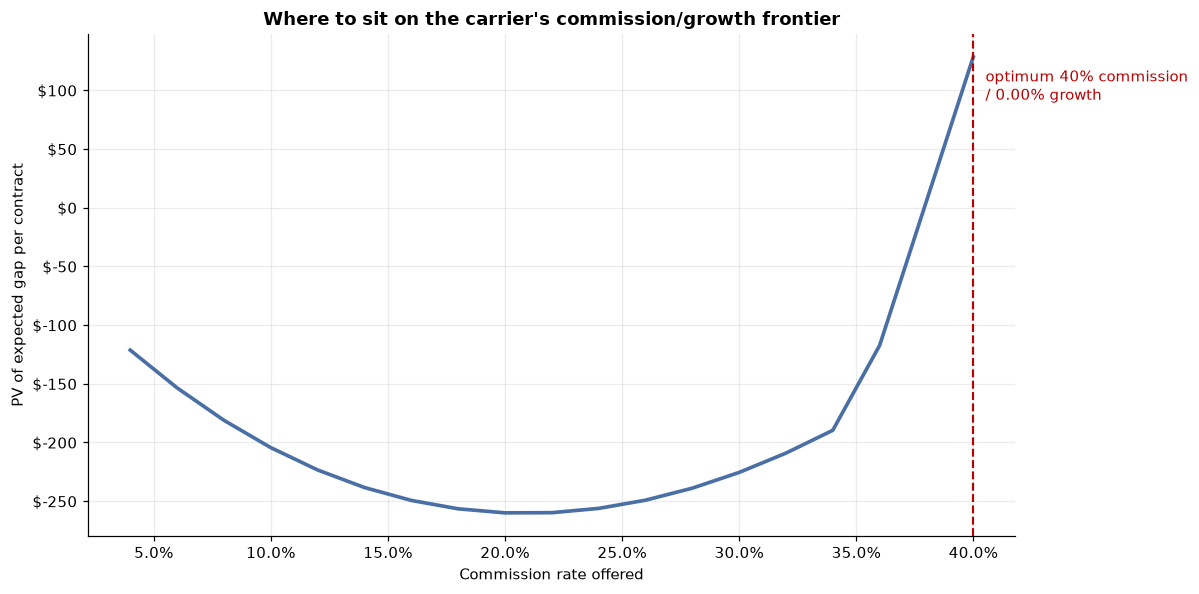

In [20]:
# Commission / growth frontier: which point on the carrier's line is best for YOU?
grid = []
for comm in np.arange(0.04, 0.42, 0.02):
    # carriers trade commission against growth roughly linearly - calibrate the slope here
    growth = 0.035 - 0.10 * comm          # <-- TWEAK: implied frontier slope
    ins = Insurance(f"c={comm:.0%}", growth_rate=max(growth, 0.0), commission_rate=comm)
    vals = np.array([evaluate(P,"insurance",True,False,int(t),ins)["gap_total"] for t in yrs])
    grid.append({"Commission": comm, "Implied growth": max(growth,0.0),
                 "PV of E[gap]": float(((vals/(1+P.econ.discount_rate)**yrs)*pmf).sum())})
fr = pd.DataFrame(grid)
best = fr.loc[fr["PV of E[gap]"].idxmax()]

fig, ax = plt.subplots()
ax.plot(fr["Commission"], fr["PV of E[gap]"], lw=2.4, color="#4a6fa5")
ax.axvline(best["Commission"], color="#b00", ls="--", lw=1.4)
ax.annotate(f"optimum {best['Commission']:.0%} commission\n"
            f"/ {best['Implied growth']:.2%} growth",
            xy=(best["Commission"], best["PV of E[gap]"]),
            xytext=(8, -28), textcoords="offset points", color="#b00")
ax.set(xlabel="Commission rate offered", ylabel="PV of expected gap per contract",
       title="Where to sit on the carrier's commission/growth frontier")
ax.xaxis.set_major_formatter(pct); ax.yaxis.set_major_formatter(usd)
plt.tight_layout(); plt.show()

## 11. Sensitivity

Which assumptions actually move the answer, and which are noise.

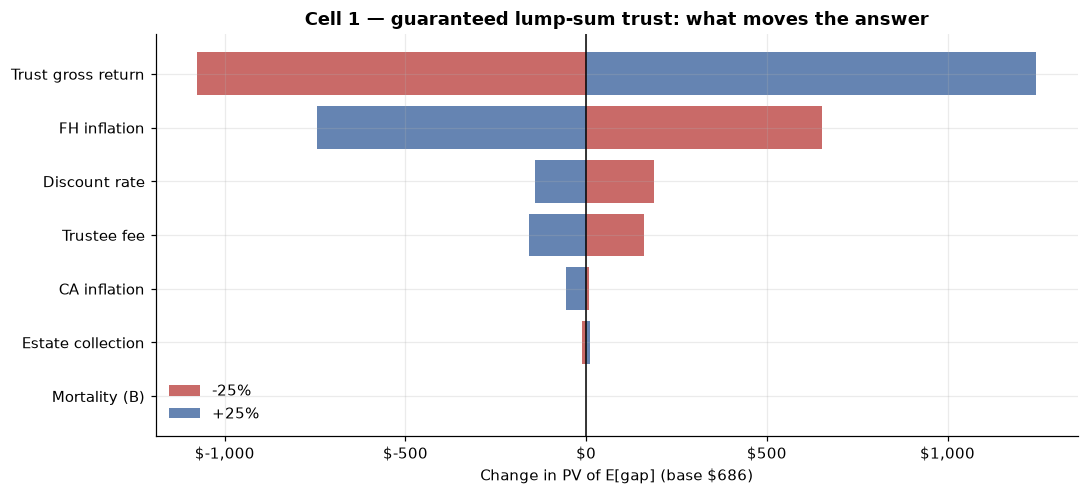

,Low,High,Swing
Driver,,,
Mortality (B),$0,$0,$0
Estate collection,$-12,$12,$23
CA inflation,$8,$-57,$65
Trustee fee,$161,$-157,$319
Discount rate,$187,$-140,$327
FH inflation,$653,$-744,"$1,396"
Trust gross return,"$-1,075","$1,245","$2,321"


In [21]:
def tornado(p, cell=1, spread=0.25):
    base_fn = lambda q: float((np.array(
        [evaluate(q, CELLS[cell-1][1], CELLS[cell-1][2]=="guaranteed", False, int(t),
                  PRODUCTS.get(CELLS[cell-1][3])) ["gap_total"] for t in yrs])
        / (1+q.econ.discount_rate)**yrs * pmf).sum())
    base = base_fn(p)
    knobs = {
        "Trust gross return":  ("trust","gross_return"),
        "Trustee fee":         ("trust","fee"),
        "FH inflation":        ("econ","fh_inflation"),
        "CA inflation":        ("econ","ca_inflation"),
        "Discount rate":       ("econ","discount_rate"),
        "Estate collection":   ("econ","estate_collection"),
        "Mortality (B)":       ("mort","B"),
    }
    rows = []
    for name, (grp, fld) in knobs.items():
        vals = []
        for mult in (1-spread, 1+spread):
            sub = getattr(p, grp)
            q = replace(p, **{grp: replace(sub, **{fld: getattr(sub, fld)*mult})})
            vals.append(base_fn(q))
        rows.append({"Driver": name, "Low": vals[0]-base, "High": vals[1]-base,
                     "Swing": abs(vals[1]-vals[0])})
    return base, pd.DataFrame(rows).sort_values("Swing").set_index("Driver")

base, tor = tornado(P, cell=1)
fig, ax = plt.subplots(figsize=(10, 4.6))
y = np.arange(len(tor))
ax.barh(y, tor["Low"],  color="#c0504d", alpha=.85, label=f"-25%")
ax.barh(y, tor["High"], color="#4a6fa5", alpha=.85, label=f"+25%")
ax.set_yticks(y); ax.set_yticklabels(tor.index); ax.axvline(0, color="k", lw=1)
ax.set(xlabel=f"Change in PV of E[gap] (base ${base:,.0f})",
       title="Cell 1 — guaranteed lump-sum trust: what moves the answer")
ax.xaxis.set_major_formatter(usd); ax.legend(frameon=False)
plt.tight_layout(); plt.show()
display(tor.style.format("${:,.0f}"))

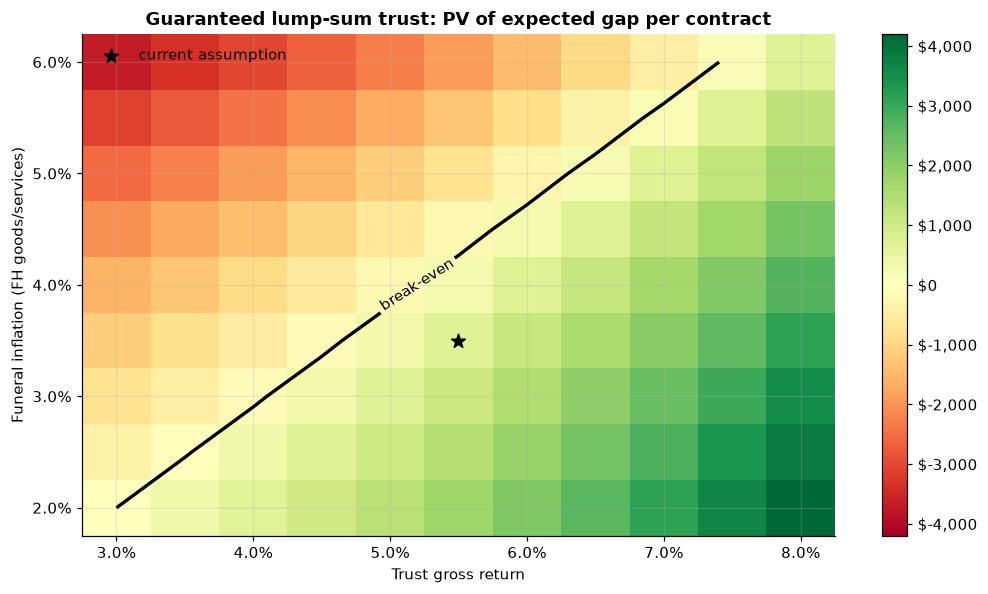

In [22]:
# 2-D: trust return x funeral inflation, guaranteed lump-sum trust
rr = np.arange(0.030, 0.081, 0.005)
ii = np.arange(0.020, 0.061, 0.005)
Z = np.zeros((len(ii), len(rr)))
for a, i_ in enumerate(ii):
    for b, r_ in enumerate(rr):
        q = replace(P, trust=replace(P.trust, gross_return=r_),
                       econ=replace(P.econ, fh_inflation=i_, ca_inflation=i_+0.01))
        v = np.array([evaluate(q,"trust",True,False,int(t))["gap_total"] for t in yrs])
        Z[a,b] = float(((v/(1+q.econ.discount_rate)**yrs)*pmf).sum())

fig, ax = plt.subplots(figsize=(9.5, 5.5))
lim = np.abs(Z).max()
im = ax.imshow(Z, origin="lower", aspect="auto", cmap="RdYlGn",
               vmin=-lim, vmax=lim,
               extent=[rr[0]-.0025, rr[-1]+.0025, ii[0]-.0025, ii[-1]+.0025])
cs = ax.contour(rr, ii, Z, levels=[0], colors="k", linewidths=2.2)
ax.clabel(cs, fmt={0: "break-even"})
ax.scatter([P.trust.gross_return], [P.econ.fh_inflation], c="k", s=90, marker="*",
           zorder=5, label="current assumption")
ax.set(xlabel="Trust gross return", ylabel="Funeral inflation (FH goods/services)",
       title="Guaranteed lump-sum trust: PV of expected gap per contract")
ax.xaxis.set_major_formatter(pct); ax.yaxis.set_major_formatter(pct)
ax.legend(frameon=False, loc="upper left")
fig.colorbar(im, ax=ax, format=usd); plt.tight_layout(); plt.show()

## 12. Scenario runner

One-line what-ifs. Pass any nested override.

In [23]:
def scenario(name, **over):
    q = P
    for grp, changes in over.items():
        q = replace(q, **{grp: replace(getattr(q, grp), **changes)})
    e = expected_value(q)
    return pd.Series({**{f"cell {i}": e.loc[i, "PV of E[gap]"] for i in e.index},
                      "name": name})

scen = pd.DataFrame([
    scenario("Base case"),
    scenario("Trust in CDs @4%",        trust=dict(gross_return=0.040,
                                                   mix=AssetMix(1,0,0,0))),
    scenario("Trust 6.5% equity-heavy", trust=dict(gross_return=0.065,
                                                   mix=AssetMix(0.20,0.25,0.50,0.05))),
    scenario("High turnover manager",   trust=dict(mix=AssetMix(0.30,0.10,0.10,0.50))),
    scenario("No QFT / filed aggregate",trust=dict(composite=False)),
    scenario("Funeral inflation 5%",    econ=dict(fh_inflation=0.05, ca_inflation=0.06)),
    scenario("5-year installments",     contract=dict(pay_years=5)),
    scenario("Younger buyer, age 62",   contract=dict(buyer_age=62)),
    scenario("Fee 1.25%",               trust=dict(fee=0.0125)),
]).set_index("name")
display(scen.style.format("${:,.0f}")
        .background_gradient(cmap="RdYlGn", axis=None)
        .set_caption("PV of expected gap per contract, by cell (see §7 for cell numbers)"))

,cell 1,cell 2,cell 3,cell 4,cell 5,cell 6,cell 7,cell 8
name,,,,,,,,
Base case,$686,$-8,$46,$372,$-315,"$1,099",$-473,$621
Trust in CDs @4%,$-654,$-159,$46,$372,$-315,"$1,099",$-473,$621
Trust 6.5% equity-heavy,"$1,671",$0,$46,$372,$-315,"$1,099",$-473,$621
High turnover manager,$403,$-22,$46,$372,$-315,"$1,099",$-473,$621
No QFT / filed aggregate,$-359,$-103,$46,$372,$-315,"$1,099",$-473,$621
Funeral inflation 5%,$-730,$-183,"$-1,370",$94,"$-1,730",$821,"$-1,889",$343
5-year installments,$-381,$-140,$46,$372,$-315,"$1,099",$-473,$621
"Younger buyer, age 62",$686,$-8,$46,$372,$-315,"$1,099",$-473,$621
Fee 1.25%,$275,$-28,$46,$372,$-315,"$1,099",$-473,$621


## 13. Guarantee-scope lever

The 4.02(5)(d) split is already on the Board's contract form. Using it costs nothing.

In [24]:
rows = []
for label, (gfh, gca) in {"Guarantee everything": (True, True),
                          "Guarantee FH only (blended)": (True, False),
                          "Guarantee nothing": (False, False)}.items():
    for veh, prod in (("trust", None), ("insurance", "growth")):
        v = np.array([evaluate(P, veh, gfh, gca, int(t),
                               PRODUCTS.get(prod))["gap_total"] for t in yrs])
        rows.append({"Scope": label, "Vehicle": veh,
                     "PV of E[gap]": float(((v/(1+P.econ.discount_rate)**yrs)*pmf).sum()),
                     "P(shortfall)": float(pmf[v < 0].sum()),
                     "Worst case": float(v.min())})
gl = pd.DataFrame(rows).pivot(index="Scope", columns="Vehicle", values="PV of E[gap]")
display(pd.DataFrame(rows).set_index(["Scope","Vehicle"])
        .style.format({"PV of E[gap]":"${:,.0f}","P(shortfall)":"{:.1%}",
                       "Worst case":"${:,.0f}"})
        .set_caption("Cost protection scope — 239 CMR 4.08(6) applied separately "
                     "to FH goods/services vs cash advances"))
for v in ("trust", "insurance"):
    lift = gl.loc["Guarantee FH only (blended)", v] - gl.loc["Guarantee everything", v]
    print(f"Leaving cash advances non-guaranteed, {v:<10}: {lift:>+9,.0f} per contract")
print()
print("Note the asymmetry: with a trust that nearly keeps pace with inflation the lever is")
print("worth little, because you give up CA surplus as well as CA shortfall. With low-growth")
print("insurance there is no surplus to give up, so it is close to free risk reduction.")

Leaving cash advances non-guaranteed, trust     :       +46 per contract
Leaving cash advances non-guaranteed, insurance :      +352 per contract

Note the asymmetry: with a trust that nearly keeps pace with inflation the lever is
worth little, because you give up CA surplus as well as CA shortfall. With low-growth
insurance there is no surplus to give up, so it is close to free risk reduction.


## 14. Notes, and what this model does *not* do

**Deliberate simplifications**

- Deterministic returns. No sequence risk. A stochastic version matters most for
  cell 1 at scale, where a drawdown coinciding with a claim cluster is the real tail —
  swap `trust_path` for a GBM or bootstrap path and re-run §9.
- Working-capital float is not modeled. Under 239 CMR 4.08(5) you must present a certified
  death certificate **and** a Type 3's certification that the contract was performed in full
  *before* payment, so you carry $4–7k per case for 1–3 weeks. And 4.08(1) bars using preneed
  funds as loan collateral, so that line of credit stands alone.
- No lapse/chargeback dynamics on installment insurance (`lapse_rate` is a stub).
- Market-share value of running a preneed program at all — the actual reason to do this —
  is outside the model. Everything here is about not losing money on the case.

**Open questions flagged in the parameters**

- `MassTax.apply_surtax_per_beneficiary` — whether the 4% Massachusetts surtax applies at the
  composite level or per beneficiary interest is unsettled. Flip it and see what it costs.
- `Trust.fee_deductible` — trustee fees under IRC §67(e) vs. the 2% floor disallowance.
- `Insurance.compound` and `growth_starts_at_paidup` — both are carrier-specific product
  facts, not assumptions. Get them in writing before trusting any output here.

**To make this yours**

1. Replace `pmf` in §9 with the empirical duration distribution from your own at-need
   conversions. That single change matters more than every other parameter combined.
2. Put your real GPL price and FH/CA split into `Contract`.
3. Get the actual commission grids and growth schedules from each carrier and calibrate the
   frontier slope in §10.
4. Ask the trustee for the last filed 1041-QFT and the matching MA Form 2, and set
   `composite` to whatever they're actually doing rather than what you hope.
